In [21]:
from google.colab import files

uploaded = files.upload()

Saving subscription_usefulness_dataset (2).csv to subscription_usefulness_dataset (2) (1).csv


In [22]:
import pandas as pd

df = pd.read_csv("subscription_usefulness_dataset (2).csv")

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())

print("\nFirst 5 records:")
display(df.head())

Dataset loaded successfully!
Dataset shape: (10000, 6)
Columns: ['No', 'App_Name', 'Monthly_Cost_LKR', 'Usage_Minutes_30D', 'Label', 'Average_Daily_Usage_Minutes']

First 5 records:


,No,App_Name,Monthly_Cost_LKR,Usage_Minutes_30D,Label,Average_Daily_Usage_Minutes
0,1,Adobe,1713,1406,Low_Usage,46.87
1,2,YouTube Premium,4824,408,Unused,13.60
2,3,Grammarly,4137,2553,Useful,85.10
3,4,Adobe,1599,2773,Useful,92.43
4,5,ChatGPT Plus,1943,1772,Useful,59.07


In [23]:
# ============================================
# SUBSCRIPTION USAGE THRESHOLD LABELING
# ============================================

def assign_label(usage_minutes):

    if 0 <= usage_minutes <= 499:
        return "Unused"

    elif 500 <= usage_minutes <= 1500:
        return "Low_Usage"

    elif 1501 <= usage_minutes <= 3000:
        return "Useful"

    else:
        return "Out_of_Range"


# Re-create labels using the new thresholds
df["Label"] = df["Usage_Minutes_30D"].apply(assign_label)

print("Thresholds applied successfully!")

print("\nThreshold Rules:")
print("0 - 499 minutes     -> Unused")
print("500 - 1500 minutes  -> Low_Usage")
print("1501 - 3000 minutes -> Useful")

print("\nLabel Distribution:")
print(df["Label"].value_counts())

Thresholds applied successfully!

Threshold Rules:
0 - 499 minutes     -> Unused
500 - 1500 minutes  -> Low_Usage
1501 - 3000 minutes -> Useful

Label Distribution:
Label
Useful       3395
Low_Usage    3344
Unused       3261
Name: count, dtype: int64


In [24]:
# ============================================
# VERIFY THRESHOLD LABELS
# ============================================

test_values = [0, 100, 499, 500, 1000, 1500, 1501, 2000, 3000]

threshold_test = pd.DataFrame({
    "Usage_Minutes_30D": test_values
})

threshold_test["Expected_Label"] = (
    threshold_test["Usage_Minutes_30D"]
    .apply(assign_label)
)

display(threshold_test)

,Usage_Minutes_30D,Expected_Label
0,0,Unused
1,100,Unused
2,499,Unused
3,500,Low_Usage
4,1000,Low_Usage
5,1500,Low_Usage
6,1501,Useful
7,2000,Useful
8,3000,Useful


In [25]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df["Label_Encoded"] = label_encoder.fit_transform(
    df["Label"]
)

print("Label Mapping:")

for i, label in enumerate(label_encoder.classes_):
    print(label, "=", i)

Label Mapping:
Low_Usage = 0
Unused = 1
Useful = 2


In [26]:
X = df[
    [
        "Monthly_Cost_LKR",
        "Usage_Minutes_30D"
    ]
]

y = df["Label_Encoded"]

print("Features:")
display(X.head())

print("\nTarget:")
print(y.head())

Features:


,Monthly_Cost_LKR,Usage_Minutes_30D
0,1713,1406
1,4824,408
2,4137,2553
3,1599,2773
4,1943,1772



Target:
0    0
1    1
2    2
3    2
4    2
Name: Label_Encoded, dtype: int64


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (8000, 2)
Testing data: (2000, 2)


In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

In [29]:
models = {

    "Logistic Regression":
        LogisticRegression(
            max_iter=1000
        ),

    "Decision Tree":
        DecisionTreeClassifier(
            random_state=42
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=100,
            random_state=42
        ),

    "XGBoost":
        XGBClassifier(
            n_estimators=200,
            max_depth=6,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            eval_metric="mlogloss"
        )
}

In [30]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

results = []

for name, model in models.items():

    print("Training:", name)

    # Train model
    model.fit(X_train, y_train)

    # Prediction
    y_pred = model.predict(X_test)

    # Accuracy
    accuracy = accuracy_score(
        y_test,
        y_pred
    )

    # Precision
    precision = precision_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    # Recall
    recall = recall_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    # F1 Score
    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted",
        zero_division=0
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

print("\nAll models trained successfully!")

Training: Logistic Regression
Training: Decision Tree
Training: Random Forest
Training: XGBoost

All models trained successfully!


In [31]:
results_df = pd.DataFrame(results)

print("\nMODEL COMPARISON")
print("=" * 70)

display(results_df)


MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.9995,0.999501,0.9995,0.999500
1,Decision Tree,1.0000,1.000000,1.0000,1.000000
2,Random Forest,1.0000,1.000000,1.0000,1.000000
3,XGBoost,0.9955,0.995517,0.9955,0.995494


In [32]:
results_percentage = results_df.copy()

for column in [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]:

    results_percentage[column] = (
        results_percentage[column] * 100
    ).round(2)

print("\nMODEL COMPARISON (%)")
print("=" * 70)

display(results_percentage)


MODEL COMPARISON (%)


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,99.95,99.95,99.95,99.95
1,Decision Tree,100.00,100.00,100.00,100.00
2,Random Forest,100.00,100.00,100.00,100.00
3,XGBoost,99.55,99.55,99.55,99.55


In [33]:
# ============================================
# SELECT BEST MODEL
# ============================================

best_index = results_df["Accuracy"].idxmax()

best_model_name = results_df.loc[
    best_index,
    "Model"
]

best_model = models[best_model_name]

print("=" * 60)
print("BEST MODEL")
print("=" * 60)

print("Best Model:", best_model_name)

print(
    "Accuracy:",
    results_df.loc[best_index, "Accuracy"] * 100,
    "%"
)

print(
    "Precision:",
    results_df.loc[best_index, "Precision"] * 100,
    "%"
)

print(
    "Recall:",
    results_df.loc[best_index, "Recall"] * 100,
    "%"
)

print(
    "F1 Score:",
    results_df.loc[best_index, "F1 Score"] * 100,
    "%"
)

BEST MODEL
Best Model: Decision Tree
Accuracy: 100.0 %
Precision: 100.0 %
Recall: 100.0 %
F1 Score: 100.0 %


Confusion Matrix:
[[669   0   0]
 [  0 652   0]
 [  0   0 679]]


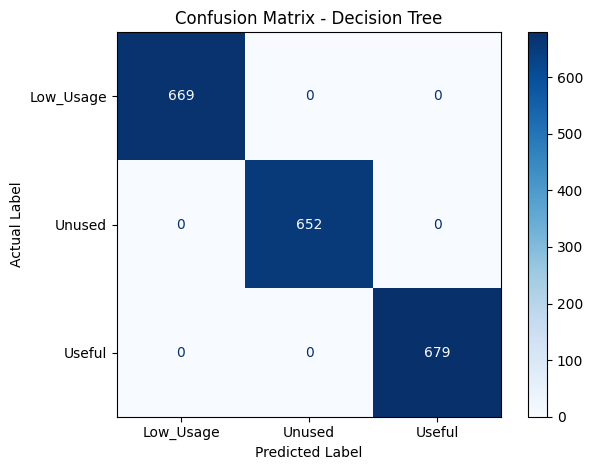

In [34]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)
import matplotlib.pyplot as plt

# Predict using best model
y_pred_best = best_model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(
    y_test,
    y_pred_best
)

print("Confusion Matrix:")
print(cm)

# Display
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title(
    f"Confusion Matrix - {best_model_name}"
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

In [35]:
print("=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred_best,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

CLASSIFICATION REPORT
              precision    recall  f1-score   support

   Low_Usage       1.00      1.00      1.00       669
      Unused       1.00      1.00      1.00       652
      Useful       1.00      1.00      1.00       679

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [36]:
# ============================================
# TEST NEW SAMPLE DATA
# ============================================

sample_data = pd.DataFrame({

    "Monthly_Cost_LKR": [
        1500,
        2000,
        3000,
        2500,
        4000
    ],

    "Usage_Minutes_30D": [
        100,
        499,
        500,
        1500,
        1501
    ]
})

print("Sample Data:")
display(sample_data)


# Predict
sample_prediction = best_model.predict(
    sample_data
)


# Convert encoded prediction
sample_labels = label_encoder.inverse_transform(
    sample_prediction
)


# Add prediction
sample_data["Predicted_Label"] = sample_labels


print("\nPrediction Results:")
display(sample_data)

Sample Data:


,Monthly_Cost_LKR,Usage_Minutes_30D
0,1500,100
1,2000,499
2,3000,500
3,2500,1500
4,4000,1501



Prediction Results:


,Monthly_Cost_LKR,Usage_Minutes_30D,Predicted_Label
0,1500,100,Unused
1,2000,499,Unused
2,3000,500,Low_Usage
3,2500,1500,Low_Usage
4,4000,1501,Useful


In [39]:
# ============================================
# SAMPLE TEST + PREDICTION PROBABILITY
# ============================================

new_data = pd.DataFrame({
    "Monthly_Cost_LKR": [2500],
    "Usage_Minutes_30D": [300]
})

# Prediction
prediction = best_model.predict(new_data)

predicted_label = label_encoder.inverse_transform(
    prediction
)[0]

# Probability
probabilities = best_model.predict_proba(new_data)

print("=" * 50)
print("SUBSCRIPTION PREDICTION")
print("=" * 50)

print("Monthly Cost:", new_data["Monthly_Cost_LKR"].iloc[0], "LKR")
print("Usage:", new_data["Usage_Minutes_30D"].iloc[0], "minutes")
print("Predicted Status:", predicted_label)

print("\nPrediction Probabilities:")
print("=" * 50)

for label, probability in zip(
    label_encoder.classes_,
    probabilities[0]
):
    print(f"{label}: {probability * 100:.2f}%")

SUBSCRIPTION PREDICTION
Monthly Cost: 2500 LKR
Usage: 300 minutes
Predicted Status: Unused

Prediction Probabilities:
Low_Usage: 0.00%
Unused: 100.00%
Useful: 0.00%


In [40]:
import joblib

joblib.dump(
    best_model,
    "best_subscription_model.pkl"
)

joblib.dump(
    label_encoder,
    "label_encoder.pkl"
)

print("Best model saved successfully!")
print("File: best_subscription_model.pkl")
print("File: label_encoder.pkl")

Best model saved successfully!
File: best_subscription_model.pkl
File: label_encoder.pkl


In [41]:
from google.colab import files

files.download(
    "best_subscription_model.pkl"
)

files.download(
    "label_encoder.pkl"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>